<a href="https://colab.research.google.com/github/kxrrym03/Faker-LOL-Performance/blob/main/Faker_LOL_Match_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving faker_complete_dataset.csv to faker_complete_dataset.csv


In [ ]:
df = pd.read_csv('faker_complete_dataset.csv')
df.shape

(573, 13)

In [ ]:
df.head()

,tournament_name,match_date,team,opponent_team,game_number,series_result,champion_played,win_loss,kills,deaths,assists,damage_dealt,game_length
0,Season 3 World Championship (Group Stage),2013-09-16,SKT T1 K,Lemondogs,1,W,Ahri,Win,10.0,3.0,9.0,NaN,34:49
1,Season 3 World Championship (Group Stage),2013-09-16,SKT T1 K,OMG,1,L,Gragas,Loss,4.0,1.0,2.0,NaN,40:06
2,Season 3 World Championship (Group Stage),2013-09-18,SKT T1 K,GamingGear,1,W,Fizz,Win,7.0,2.0,7.0,NaN,29:38
3,Season 3 World Championship (Group Stage),2013-09-18,SKT T1 K,Team SoloMid,1,W,Ahri,Win,2.0,2.0,7.0,NaN,34:15
4,Season 3 World Championship (Group Stage),2013-09-21,SKT T1 K,Lemondogs,1,W,Riven,Win,4.0,3.0,7.0,NaN,28:43


In [ ]:
df.tail()

,tournament_name,match_date,team,opponent_team,game_number,series_result,champion_played,win_loss,kills,deaths,assists,damage_dealt,game_length
568,MSI 2026 (Lower Bracket),2026-07-06,T1,FURIA,3,W 3-0,Taliyah,Win,1.0,3.0,9.0,24793.0,35:16
569,MSI 2026 (Lower Bracket Final - eliminated),2026-07-08,T1,G2 Esports,1,L 1-3,Cassiopeia,Loss,6.0,5.0,6.0,35894.0,45:54
570,MSI 2026 (Lower Bracket Final - eliminated),2026-07-08,T1,G2 Esports,2,L 1-3,Ryze,Loss,3.0,2.0,2.0,17082.0,31:24
571,MSI 2026 (Lower Bracket Final - eliminated),2026-07-08,T1,G2 Esports,3,L 1-3,Sylas,Win,6.0,4.0,15.0,28510.0,30:14
572,MSI 2026 (Lower Bracket Final - eliminated),2026-07-08,T1,G2 Esports,4,L 1-3,Galio,Loss,5.0,8.0,13.0,37041.0,50:57


In [ ]:
df.isnull().sum()

,0
tournament_name,0
match_date,0
team,0
opponent_team,0
game_number,0
series_result,0
champion_played,0
win_loss,0
kills,4
deaths,4


In [ ]:
for col in ['kills', 'deaths', 'assists', 'damage_dealt']:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

In [ ]:
print('Null values after imputation:')
display(df.isnull().sum())

Null values after imputation:


,0
tournament_name,0
match_date,0
team,0
opponent_team,0
game_number,0
series_result,0
champion_played,0
win_loss,0
kills,0
deaths,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tournament_name  573 non-null    object 
 1   match_date       573 non-null    object 
 2   team             573 non-null    object 
 3   opponent_team    573 non-null    object 
 4   game_number      573 non-null    int64  
 5   series_result    573 non-null    object 
 6   champion_played  573 non-null    object 
 7   win_loss         573 non-null    object 
 8   kills            573 non-null    float64
 9   deaths           573 non-null    float64
 10  assists          573 non-null    float64
 11  damage_dealt     573 non-null    float64
 12  game_length      573 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 58.3+ KB


In [ ]:
df.describe()

,game_number,kills,deaths,assists,damage_dealt
count,573.000000,573.000000,573.000000,573.000000,573.000000
mean,2.223386,3.438045,2.321117,5.659686,18283.160558
std,1.185140,2.468349,1.741570,3.452130,7544.955112
min,1.000000,0.000000,0.000000,0.000000,3961.000000
25%,1.000000,1.000000,1.000000,3.000000,13536.000000
50%,2.000000,3.000000,2.000000,5.000000,17471.000000
75%,3.000000,5.000000,3.000000,8.000000,21247.000000
max,5.000000,15.000000,8.000000,22.000000,65484.000000


In [ ]:
df.columns

Index(['tournament_name', 'match_date', 'team', 'opponent_team', 'game_number',
       'series_result', 'champion_played', 'win_loss', 'kills', 'deaths',
       'assists', 'damage_dealt', 'game_length'],
      dtype='object')

In [ ]:
df.dtypes

,0
tournament_name,object
match_date,object
team,object
opponent_team,object
game_number,int64
series_result,object
champion_played,object
win_loss,object
kills,float64
deaths,float64


## Data Preparation for Analysis

In [ ]:
# Convert match_date to datetime objects
df['match_date'] = pd.to_datetime(df['match_date'])

# Extract year, month, and day of week
df['match_year'] = df['match_date'].dt.year
df['match_month'] = df['match_date'].dt.month
df['match_dayofweek'] = df['match_date'].dt.dayofweek

# Convert game_length from MM:SS string to total seconds
def convert_game_length_to_seconds(time_str):
    if pd.isna(time_str):
        return np.nan
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

df['game_length_seconds'] = df['game_length'].apply(convert_game_length_to_seconds)


print("Data types after conversion and feature extraction:")
display(df.dtypes)
display(df.head())

Data types after conversion and feature extraction:


,0
tournament_name,object
match_date,datetime64[ns]
team,object
opponent_team,object
game_number,int64
series_result,object
champion_played,object
win_loss,object
kills,float64
deaths,float64


,tournament_name,match_date,team,opponent_team,game_number,series_result,champion_played,win_loss,kills,deaths,assists,damage_dealt,game_length,match_year,match_month,match_dayofweek,game_length_seconds
0,Season 3 World Championship (Group Stage),2013-09-16,SKT T1 K,Lemondogs,1,W,Ahri,Win,10.0,3.0,9.0,17471.0,34:49,2013,9,0,2089
1,Season 3 World Championship (Group Stage),2013-09-16,SKT T1 K,OMG,1,L,Gragas,Loss,4.0,1.0,2.0,17471.0,40:06,2013,9,0,2406
2,Season 3 World Championship (Group Stage),2013-09-18,SKT T1 K,GamingGear,1,W,Fizz,Win,7.0,2.0,7.0,17471.0,29:38,2013,9,2,1778
3,Season 3 World Championship (Group Stage),2013-09-18,SKT T1 K,Team SoloMid,1,W,Ahri,Win,2.0,2.0,7.0,17471.0,34:15,2013,9,2,2055
4,Season 3 World Championship (Group Stage),2013-09-21,SKT T1 K,Lemondogs,1,W,Riven,Win,4.0,3.0,7.0,17471.0,28:43,2013,9,5,1723


In [ ]:
avg_kills_by_year = df.groupby('match_year')['kills'].mean().reset_index()
print("Average Kills by Year:")
display(avg_kills_by_year)

Average Kills by Year:


,match_year,kills
0,2013,4.444444
1,2014,7.000000
2,2015,4.931034
3,2016,4.000000
4,2017,3.035714
5,2018,2.166667
6,2019,3.777778
7,2020,2.769231
8,2021,2.620690
9,2022,3.035088


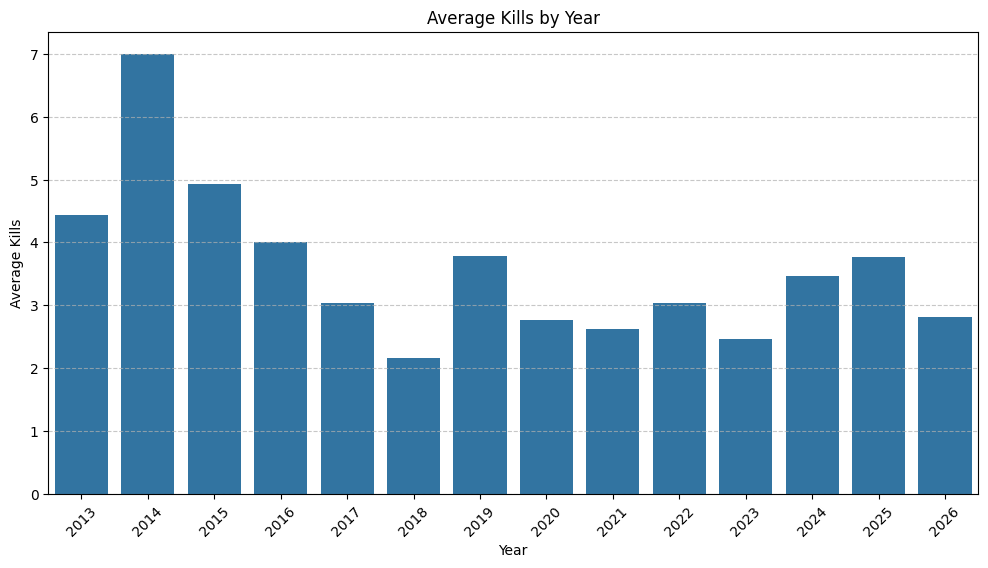

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='match_year', y='kills', data=avg_kills_by_year)
plt.title('Average Kills by Year')
plt.xlabel('Year')
plt.ylabel('Average Kills')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Total Kills per Team

In [ ]:
total_kills_by_team = df.groupby('team')['kills'].sum().reset_index()
total_kills_by_team = total_kills_by_team.sort_values(by='kills', ascending=False)
print("Total Kills by Team:")
display(total_kills_by_team)

Total Kills by Team:


,team,kills
4,T1,1050.0
1,SKT,472.0
2,SKT T1,274.0
3,SKT T1 K,143.0
0,LCK Allstars,31.0


## Average Game Length for Top 3 Teams

In [ ]:
# Get the top 3 teams based on total kills
top_3_teams = total_kills_by_team['team'].head(3).tolist()
print(f"Top 3 teams by total kills: {top_3_teams}")

# Filter the DataFrame for these top 3 teams
df_top_teams = df[df['team'].isin(top_3_teams)]

# Calculate the average game length for these teams
avg_game_length_top_teams = df_top_teams.groupby('team')['game_length_seconds'].mean().reset_index()
avg_game_length_top_teams = avg_game_length_top_teams.sort_values(by='game_length_seconds', ascending=False)

print("Average Game Length (seconds) for Top 3 Teams:")
display(avg_game_length_top_teams)


Top 3 teams by total kills: ['T1', 'SKT', 'SKT T1']
Average Game Length (seconds) for Top 3 Teams:


,team,game_length_seconds
1,SKT T1,2165.967213
0,SKT,2104.751773
2,T1,1910.923077


## Correlation Between Match Duration and Kills

In [ ]:
correlation = df['game_length_seconds'].corr(df['kills'])
print(f"Correlation between game length and kills: {correlation:.2f}")

Correlation between game length and kills: 0.01


## Average Kills per Team

In [ ]:
average_kills_per_team = df.groupby('team')['kills'].mean().reset_index()
average_kills_per_team = average_kills_per_team.sort_values(by='kills', ascending=False)
print("Average Kills per Team:")
display(average_kills_per_team)

Average Kills per Team:


,team,kills
3,SKT T1 K,5.296296
0,LCK Allstars,5.166667
2,SKT T1,4.491803
1,SKT,3.347518
4,T1,3.106509


## Tournament with Highest Average Kills

In [ ]:
avg_kills_by_tournament = df.groupby('tournament_name')['kills'].mean().reset_index()
highest_avg_kills_tournament = avg_kills_by_tournament.sort_values(by='kills', ascending=False).iloc[0]

print("Tournament with the Highest Average Kills:")
display(highest_avg_kills_tournament)

Tournament with the Highest Average Kills:


,56
tournament_name,LCK Summer Playoffs 2019 (Round 2)
kills,7.333333


## Average Kills per Year (Line Plot)

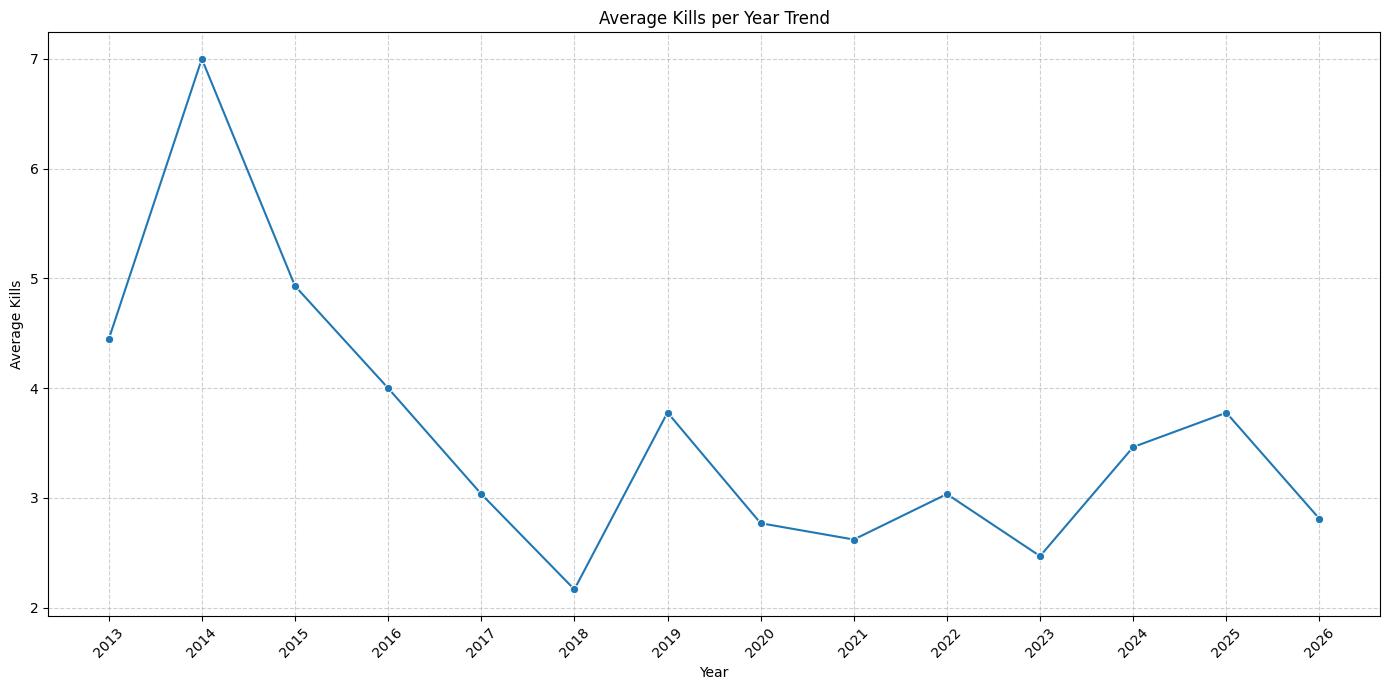

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='match_year', y='kills', data=avg_kills_by_year, marker='o')
plt.title('Average Kills per Year Trend')
plt.xlabel('Year')
plt.ylabel('Average Kills')
plt.xticks(avg_kills_by_year['match_year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Data Visualization

### Distribution of Win/Loss Outcomes

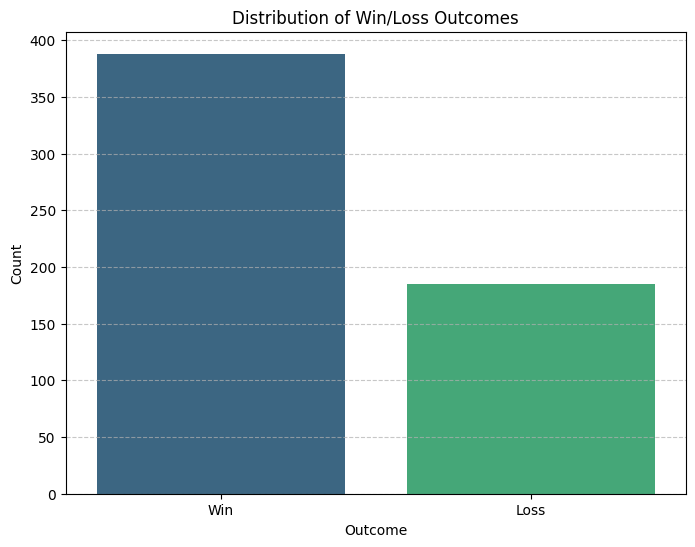

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='win_loss', data=df, palette='viridis')
plt.title('Distribution of Win/Loss Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Trend of Average Game Length Over Years

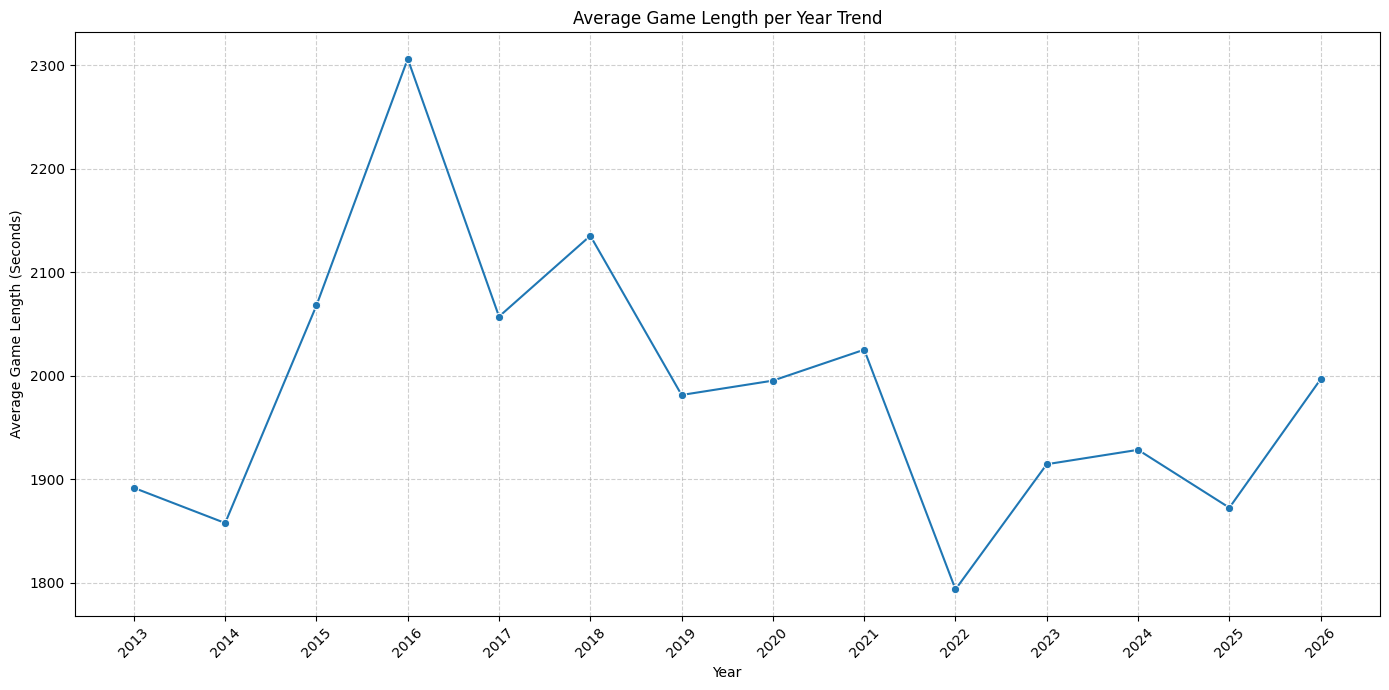

In [ ]:
avg_game_length_by_year = df.groupby('match_year')['game_length_seconds'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='match_year', y='game_length_seconds', data=avg_game_length_by_year, marker='o')
plt.title('Average Game Length per Year Trend')
plt.xlabel('Year')
plt.ylabel('Average Game Length (Seconds)')
plt.xticks(avg_game_length_by_year['match_year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Total Kills Per Year Trend

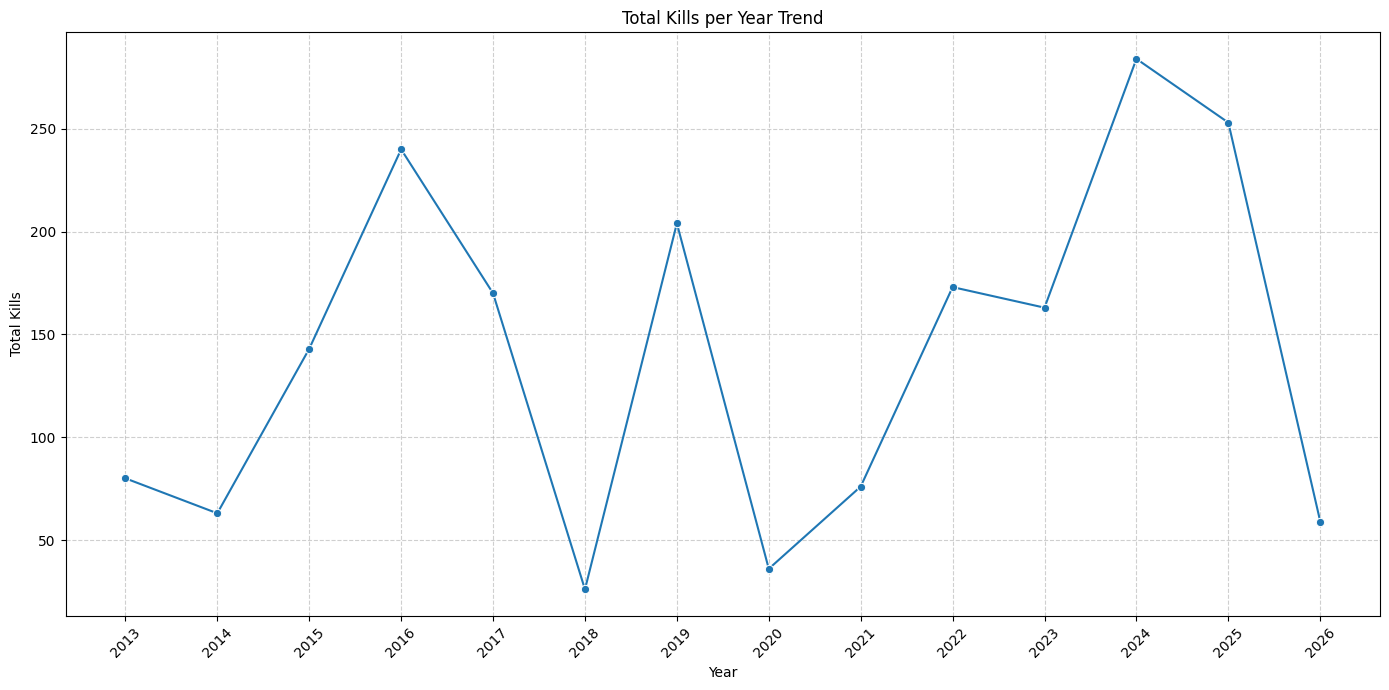

In [ ]:
total_kills_by_year = df.groupby('match_year')['kills'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='match_year', y='kills', data=total_kills_by_year, marker='o')
plt.title('Total Kills per Year Trend')
plt.xlabel('Year')
plt.ylabel('Total Kills')
plt.xticks(total_kills_by_year['match_year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Average Kills Per Team

### Total Kills Per Team (Bar Chart)

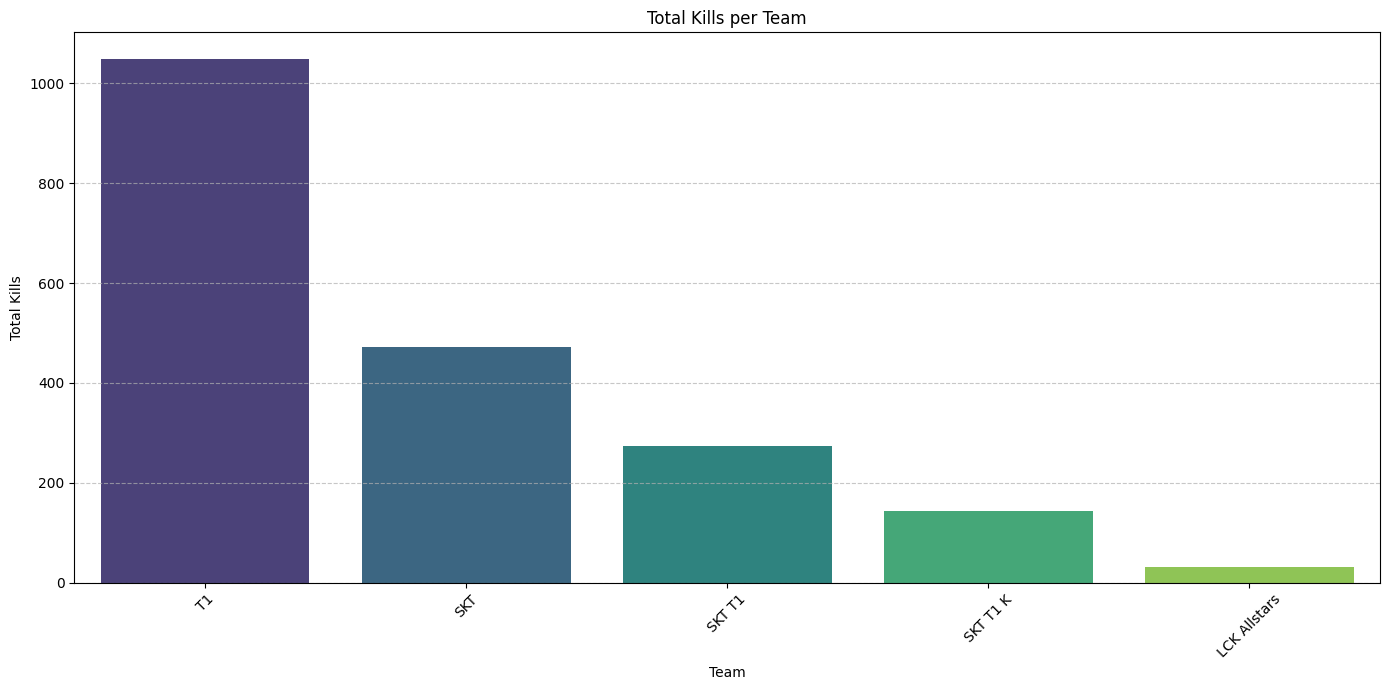

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='kills', data=total_kills_by_team, palette='viridis')
plt.title('Total Kills per Team')
plt.xlabel('Team')
plt.ylabel('Total Kills')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Boxplot of Game Lengths

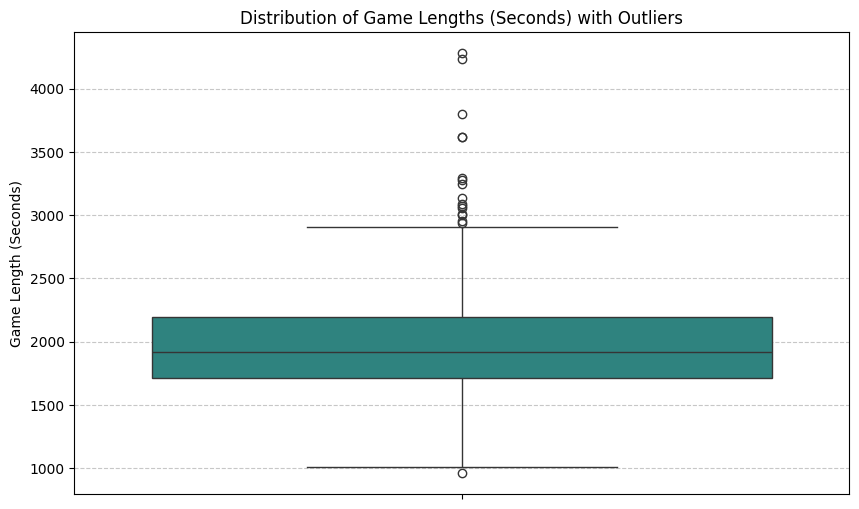

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['game_length_seconds'], palette='viridis')
plt.title('Distribution of Game Lengths (Seconds) with Outliers')
plt.ylabel('Game Length (Seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Scatter Plot of Total Kills vs Game Duration

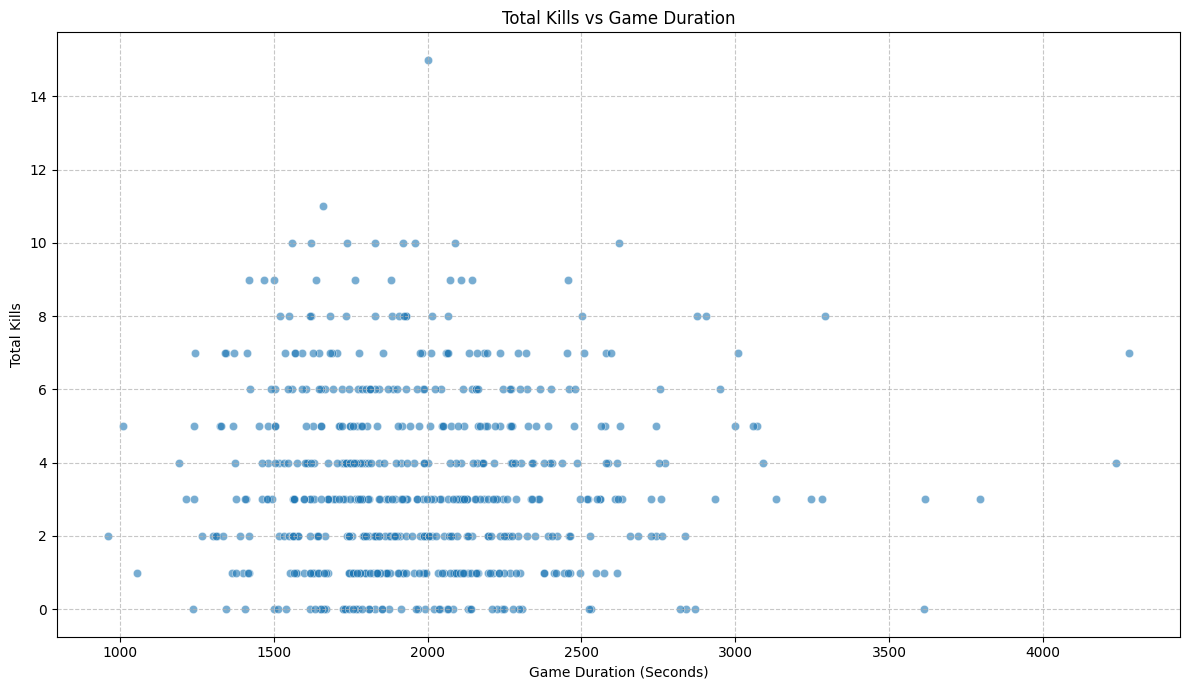

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='game_length_seconds', y='kills', data=df, alpha=0.6)
plt.title('Total Kills vs Game Duration')
plt.xlabel('Game Duration (Seconds)')
plt.ylabel('Total Kills')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

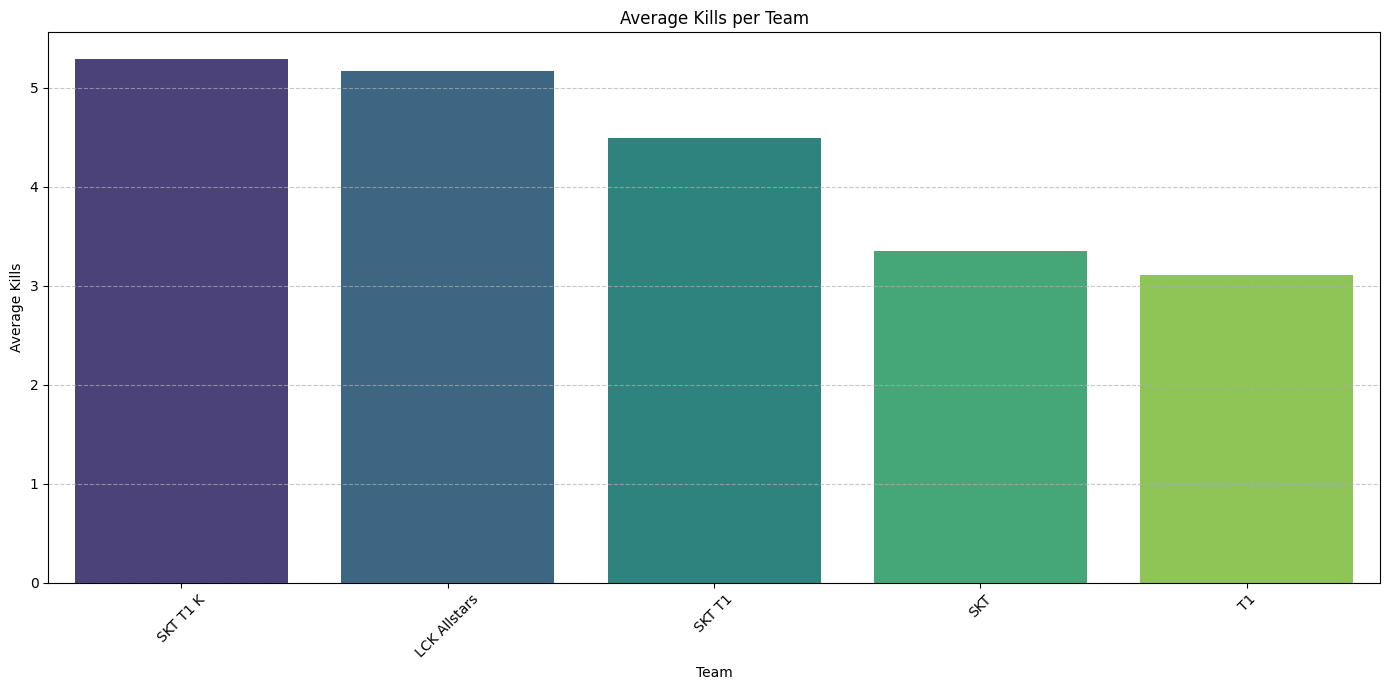

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='kills', data=average_kills_per_team, palette='viridis')
plt.title('Average Kills per Team')
plt.xlabel('Team')
plt.ylabel('Average Kills')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Kill Distribution by Tournament and Year (Heatmap)

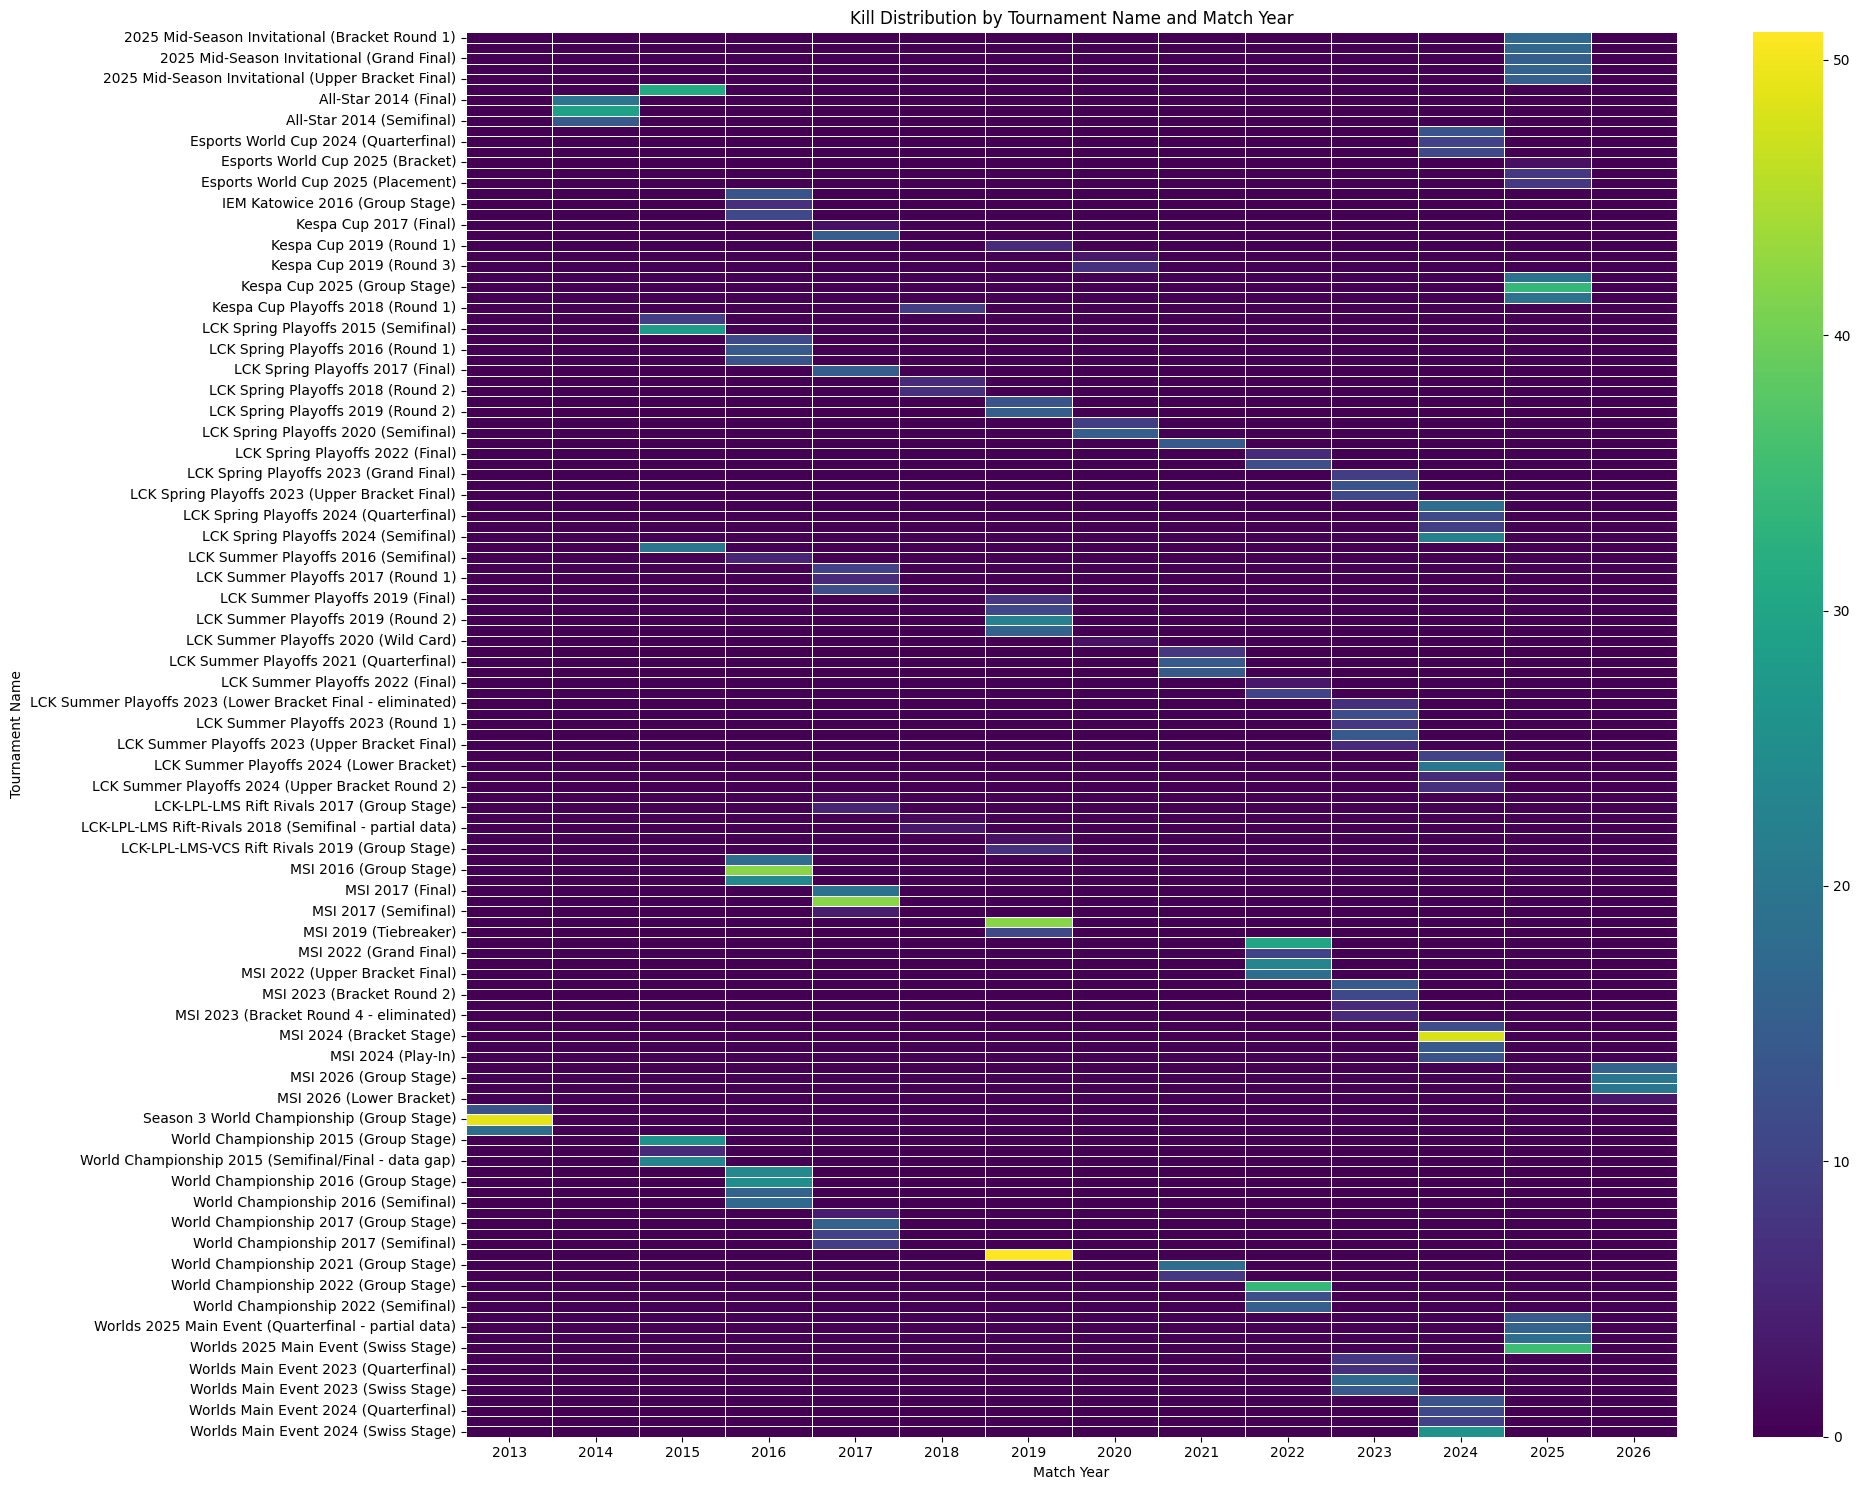

In [ ]:
kills_by_tournament_year = df.groupby(['tournament_name', 'match_year'])['kills'].sum().unstack(fill_value=0)

plt.figure(figsize=(20, 15))
sns.heatmap(kills_by_tournament_year, cmap='viridis', annot=False, fmt='g', linewidths=.5)
plt.title('Kill Distribution by Tournament Name and Match Year')
plt.xlabel('Match Year')
plt.ylabel('Tournament Name')
plt.tight_layout()
plt.show()

## Average Game Length for Top 5 Teams

Top 5 teams by total kills: ['T1', 'SKT', 'SKT T1', 'SKT T1 K', 'LCK Allstars']
Average Game Length (seconds) for Top 5 Teams:


,team,game_length_seconds
2,SKT T1,2165.967213
1,SKT,2104.751773
4,T1,1910.923077
3,SKT T1 K,1880.555556
0,LCK Allstars,1708.833333


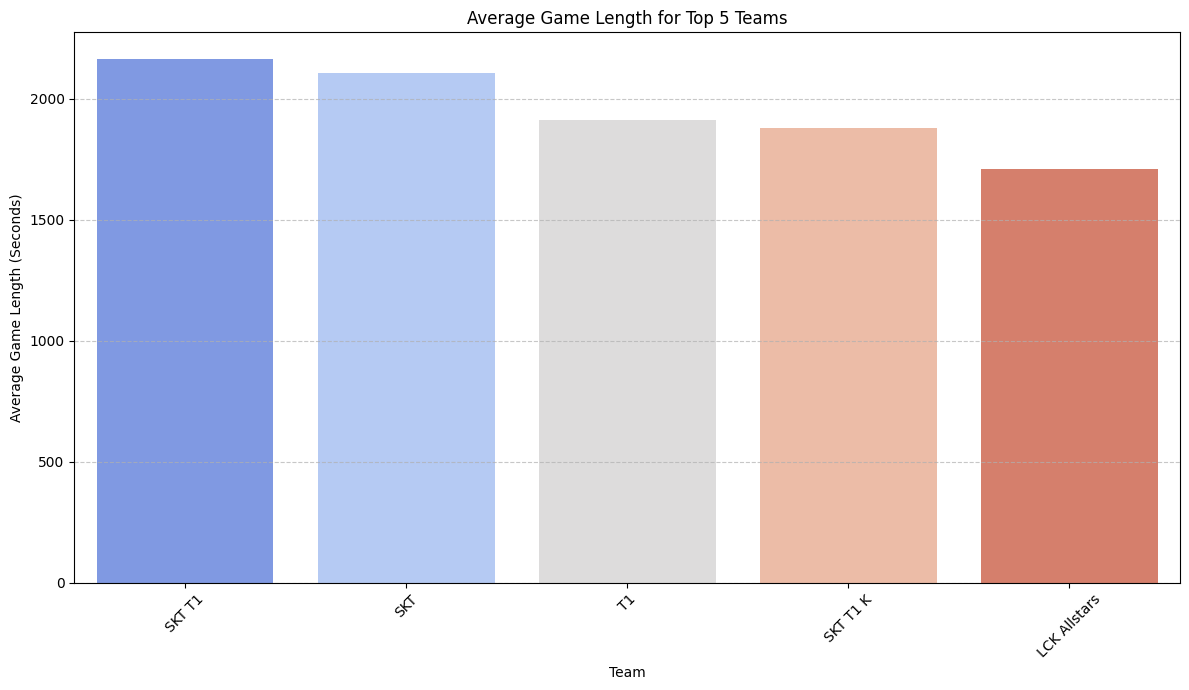

In [ ]:
# Top 5 teams based on total kills
top_5_teams = total_kills_by_team['team'].head(5).tolist()
print(f"Top 5 teams by total kills: {top_5_teams}")

# Filter the DataFrame for these top 5 teams
df_top_5_teams = df[df['team'].isin(top_5_teams)]

# Calculate the average game length for these teams
avg_game_length_top_5_teams = df_top_5_teams.groupby('team')['game_length_seconds'].mean().reset_index()
avg_game_length_top_5_teams = avg_game_length_top_5_teams.sort_values(by='game_length_seconds', ascending=False)

print("Average Game Length (seconds) for Top 5 Teams:")
display(avg_game_length_top_5_teams)

plt.figure(figsize=(12, 7))
sns.barplot(x='team', y='game_length_seconds', data=avg_game_length_top_5_teams, palette='coolwarm')
plt.title('Average Game Length for Top 5 Teams')
plt.xlabel('Team')
plt.ylabel('Average Game Length (Seconds)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Average Game Length for All Teams

In [ ]:
avg_game_length_all_teams = df.groupby('team')['game_length_seconds'].mean().reset_index()
avg_game_length_all_teams = avg_game_length_all_teams.sort_values(by='game_length_seconds', ascending=False)

print("Average Game Length (seconds) for All Teams:")
display(avg_game_length_all_teams)

# Provide summary
min_length = avg_game_length_all_teams['game_length_seconds'].min()
max_length = avg_game_length_all_teams['game_length_seconds'].max()
range_length = max_length - min_length

print(f"\nThe average game length across all teams ranges from {min_length:.2f} seconds to {max_length:.2f} seconds, with a total difference of {range_length:.2f} seconds. The team with the longest average game length is {avg_game_length_all_teams.iloc[0]['team']} and the team with the shortest is {avg_game_length_all_teams.iloc[-1]['team']}.")

Average Game Length (seconds) for All Teams:


,team,game_length_seconds
2,SKT T1,2165.967213
1,SKT,2104.751773
4,T1,1910.923077
3,SKT T1 K,1880.555556
0,LCK Allstars,1708.833333



The average game length across all teams ranges from 1708.83 seconds to 2165.97 seconds, with a total difference of 457.13 seconds. The team with the longest average game length is SKT T1 and the team with the shortest is LCK Allstars.


## Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import lightgbm as lgb

### Feature Engineering and Data Splitting

In [ ]:
# Define target variable and features
y = df['win_loss']
X = df.drop(['win_loss', 'match_date', 'tournament_name', 'team', 'opponent_team', 'series_result', 'game_length'], axis=1)

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Identify categorical and numerical features for X
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

X_train shape: (458, 70)
X_test shape: (115, 70)
y_train shape: (458,)
y_test shape: (115,)


,game_number,kills,deaths,assists,damage_dealt,match_year,match_month,match_dayofweek,game_length_seconds,champion_played_Akali,...,champion_played_VelKoz,champion_played_Vex,champion_played_Viktor,champion_played_Xerath,champion_played_Yasuo,champion_played_Yone,champion_played_Zac,champion_played_Zed,champion_played_Zilean,champion_played_Zoe
333,-0.188654,0.227863,1.539544,-1.061050,3.394745,2022,11,5,1.867377,False,...,False,False,True,False,False,False,False,False,False,False
28,-0.188654,-0.988586,-0.184545,-1.640909,-0.107737,2015,4,4,-0.320132,False,...,False,False,False,True,False,False,False,False,False,False
371,-1.033173,-0.177620,-0.184545,0.968455,-1.011779,2023,8,3,-0.983014,False,...,False,False,False,False,False,False,False,False,False,False
331,1.500385,-0.177620,0.390151,1.548314,0.198828,2022,10,5,-1.158204,False,...,False,False,False,False,False,False,False,False,False,False
94,1.500385,-0.988586,2.114240,-1.640909,-0.107737,2016,8,4,1.093226,False,...,False,False,False,False,False,False,False,False,False,False


### RandomForestClassifier Training and Evaluation

Random Forest Classifier Metrics:
Accuracy: 0.8522
Precision: 0.8588
Recall: 0.9359
F1 Score: 0.8957
ROC AUC Score: 0.9357


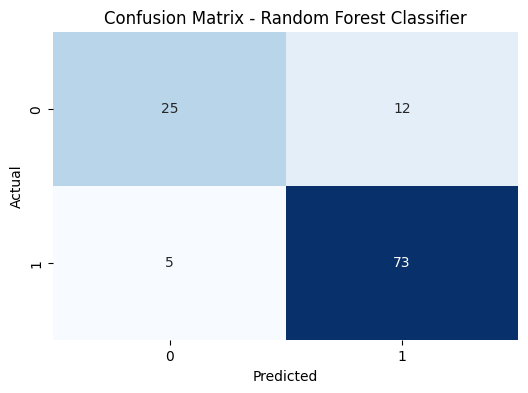

In [ ]:
# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Display confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()